Calcul Parallèle version 2

In [1]:
import multiprocessing

num_cores = multiprocessing.cpu_count()
print(f"Nombre de cœurs CPU disponibles : {num_cores}")


Nombre de cœurs CPU disponibles : 24


In [2]:
#base_path = r"D:\wealth_predict_sentinel"

### Modèle 1:Couche Initiale nongelée - Fully Convolutional

✅ Accès confirmé : D:\wealth_predict_sentinel\Data\processed_csv
✅ Accès confirmé : D:\wealth_predict_sentinel\models
✅ Accès confirmé : D:\wealth_predict_sentinel\figures_graphs
✅ Fichier mis à jour et sauvegardé : D:\wealth_predict_sentinel\Data\processed_csv\EHCVM_2018_images_with_features_extracted_4096_fullyConv_sans_augm_couche_nongelee_batch_16_version_2.csv
✅ Modèle sauvegardé : D:\wealth_predict_sentinel\models\fullyConv_sans_augm_couche_nongelee_batch_16_logistic_sans_pca_5-fold.pkl

✅ Rapport de classification (Test Set) :
               precision    recall  f1-score   support

           0       0.75      0.61      0.67      8439
           1       0.46      0.63      0.53      4541

    accuracy                           0.61     12980
   macro avg       0.61      0.62      0.60     12980
weighted avg       0.65      0.61      0.62     12980



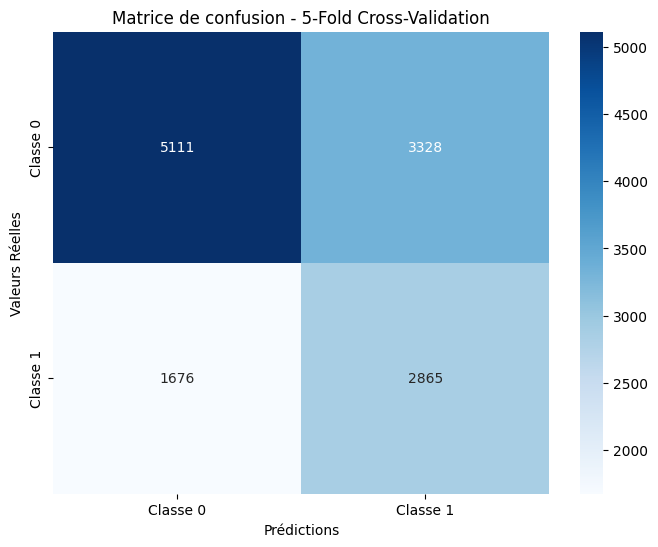

✅ Matrice de confusion sauvegardée : D:\wealth_predict_sentinel\figures_graphs\fullyConv_sans_augm_couche_nongelee_batch_16_conf_matrix_sans_pca_5-fold.png


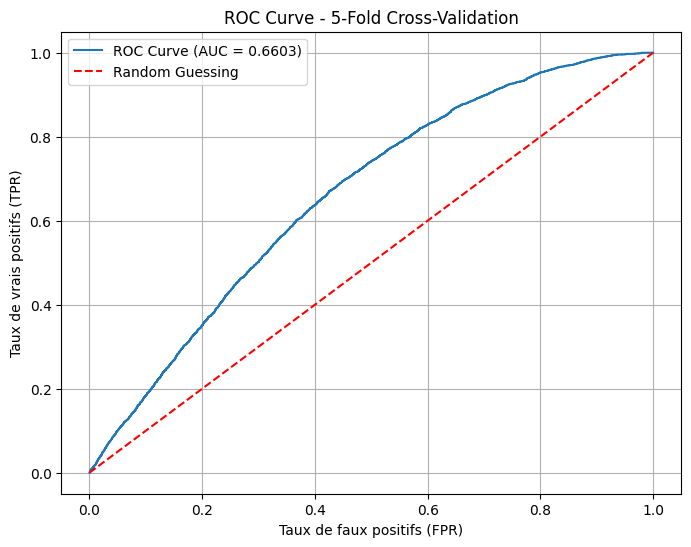

✅ Courbe ROC sauvegardée : D:\wealth_predict_sentinel\figures_graphs\fullyConv_sans_augm_couche_nongelee_batch_16_roc_curve_sans_pca_5-fold.png

✅ Taux de pauvreté réel : 39.4405%
✅ Taux de pauvreté prédit : 39.8217%
✅ Fichier final sauvegardé : D:\wealth_predict_sentinel\Data\processed_csv\fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_sans_pca_5-fold.csv
✅ Processus terminé avec succès en 0h 58m 39s.


In [3]:
import time
import os
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from joblib import Parallel, delayed
from sklearn.base import clone

start_time = time.time()

# ===============================
# 1️⃣ Définition des chemins
# ===============================
base_dir = r"D:\wealth_predict_sentinel"
data_dir = os.path.join(base_dir, "Data", "processed_csv")
models_dir = os.path.join(base_dir, "models")
figures_dir = os.path.join(base_dir, "figures_graphs")

for path in [data_dir, models_dir, figures_dir]:
   os.makedirs(path, exist_ok=True)
   print(f"✅ Accès confirmé : {path}")

# ===============================
# 2️⃣ CHARGEMENT DES DONNÉES
# ===============================
input_csv = os.path.join(data_dir, "EHCVM_2018_images_with_features_extracted_4096_fullyConv_sans_augm_couche_nongelee_batch_16_version_2.csv")
df = pd.read_csv(input_csv)

if 'pcexp_binaire' not in df.columns and 'pcexp' in df.columns and 'zref' in df.columns:
   df['pcexp_binaire'] = (df['pcexp'] <= df['zref']).astype(int)
   print("✅ La colonne 'pcexp_binaire' a été ajoutée avec succès.")

df.to_csv(input_csv, index=False)
print(f"✅ Fichier mis à jour et sauvegardé : {input_csv}")

# ===============================
# 3️⃣ PRÉTRAITEMENT DES DONNÉES
# ===============================
features = [f'feature_{i}' for i in range(4096)]
target_binary = 'pcexp_binaire'

X = df[features]
y = df[target_binary]

k = 5

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===============================
# 4️⃣ ENTRAÎNEMENT DU MODÈLE AVEC VALIDATION CROISÉE PARALLÈLE
# ===============================
def train_and_predict_fold(train_idx, test_idx, X, y, base_model):
   model = clone(base_model)
   X_train, X_test = X[train_idx], X[test_idx]
   y_train, y_test = y[train_idx], y[test_idx]

   model.fit(X_train, y_train)

   pred = model.predict(X_test)
   proba = model.predict_proba(X_test)[:, 1]

   return test_idx, pred, proba

base_model = LogisticRegression(
   class_weight='balanced',
   max_iter=10000,
   solver='saga',
   random_state=42,
   n_jobs=15
)

kf = KFold(n_splits=k, shuffle=True, random_state=42)

results = Parallel(n_jobs=-1)(
   delayed(train_and_predict_fold)(
       train_idx, test_idx, X_scaled, y, base_model
   )
   for train_idx, test_idx in kf.split(X_scaled)
)

y_pred = np.zeros_like(y, dtype=float)
y_proba = np.zeros_like(y, dtype=float)

for test_idx, pred, proba in results:
   y_pred[test_idx] = pred
   y_proba[test_idx] = proba

logistic_model = LogisticRegression(
   class_weight='balanced',
   max_iter=10000,
   solver='saga',
   random_state=42,
   n_jobs=15
)
logistic_model.fit(X_scaled, y)

# ===============================
# 5️⃣ SAUVEGARDE DU MODÈLE
# ===============================
logistic_model_path = os.path.join(models_dir, f"fullyConv_sans_augm_couche_nongelee_batch_16_logistic_sans_pca_{k}-fold.pkl")
with open(logistic_model_path, 'wb') as file:
   pickle.dump((logistic_model, scaler), file)
print(f"✅ Modèle sauvegardé : {logistic_model_path}")

# ===============================
# 6️⃣ ÉVALUATION DU MODÈLE
# ===============================
print("\n✅ Rapport de classification (Test Set) :\n", classification_report(y, y_pred))

# ===============================
# 7️⃣ MATRICE DE CONFUSION
# ===============================
conf_matrix = confusion_matrix(y, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Classe 0', 'Classe 1'], yticklabels=['Classe 0', 'Classe 1'])
plt.title(f"Matrice de confusion - {k}-Fold Cross-Validation")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs Réelles")
conf_matrix_path = os.path.join(figures_dir, f"fullyConv_sans_augm_couche_nongelee_batch_16_conf_matrix_sans_pca_{k}-fold.png")
plt.savefig(conf_matrix_path)
plt.show()
print(f"✅ Matrice de confusion sauvegardée : {conf_matrix_path}")

# ===============================
# 8️⃣ COURBE ROC ET AUC
# ===============================
fpr, tpr, _ = roc_curve(y, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', label="Random Guessing")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title(f"ROC Curve - {k}-Fold Cross-Validation")
plt.legend()
plt.grid(True)
roc_curve_path = os.path.join(figures_dir, f"fullyConv_sans_augm_couche_nongelee_batch_16_roc_curve_sans_pca_{k}-fold.png")
plt.savefig(roc_curve_path)
plt.show()
print(f"✅ Courbe ROC sauvegardée : {roc_curve_path}")

# ===============================
# 9️⃣ CALCUL DU TAUX DE PAUVRETÉ
# ===============================
df['pcexp_binaire_pred'] = y_pred

weighted_real_poverty = (
   (df['hhweight'] * df['hhsize'] * df[target_binary]).sum() /
   (df['hhweight'] * df['hhsize']).sum()
)

weighted_predicted_poverty = (
   (df['hhweight'] * df['hhsize'] * df['pcexp_binaire_pred']).sum() /
   (df['hhweight'] * df['hhsize']).sum()
)

print(f"\n✅ Taux de pauvreté réel : {weighted_real_poverty:.4%}")
print(f"✅ Taux de pauvreté prédit : {weighted_predicted_poverty:.4%}")

# ===============================
# 🔟 SAUVEGARDE DES RÉSULTATS FINAUX
# ===============================
final_csv_path = os.path.join(data_dir, f"fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_sans_pca_{k}-fold.csv")
df.to_csv(final_csv_path, index=False)
print(f"✅ Fichier final sauvegardé : {final_csv_path}")

end_time = time.time()
execution_time = end_time - start_time
hours = int(execution_time // 3600)
minutes = int((execution_time % 3600) // 60)
seconds = int(execution_time % 60)

print(f"✅ Processus terminé avec succès en {hours}h {minutes}m {seconds}s.")

In [4]:
import time
import pandas as pd
import numpy as np
import os

start_time = time.time()

# Chargement des données
data_dir = os.path.join(base_dir, "Data", "processed_csv")
input_file = os.path.join(data_dir, "fullyConv_sans_augm_couche_nongelee_batch_16_test_with_poverty_sans_pca_5-fold.csv")

df = pd.read_csv(input_file)

def calculate_poverty_ci(df, y_proba, n_bootstrap=1000, confidence=0.95):
    np.random.seed(42)
    bootstrap_rates = []

    for _ in range(n_bootstrap):
        indices = np.random.randint(0, len(df), size=len(df))
        sample_df = df.iloc[indices]
        sample_proba = y_proba[indices]

        sample_pred = (sample_proba >= 0.5).astype(int)

        weighted_poverty = (
            (sample_df['hhweight'] * sample_df['hhsize'] * sample_pred).sum() /
            (sample_df['hhweight'] * sample_df['hhsize']).sum()
        )
        bootstrap_rates.append(weighted_poverty)

    alpha = 1 - confidence
    lower = np.percentile(bootstrap_rates, alpha/2 * 100)
    upper = np.percentile(bootstrap_rates, (1 - alpha/2) * 100)

    return lower, upper

# Calcul de l'intervalle de confiance
y_proba = df['pcexp_binaire_pred']  # Utilise les prédictions sauvegardées
lower_ci, upper_ci = calculate_poverty_ci(df, y_proba)
print(f"\n✅ Intervalle de confiance à 95% du taux de pauvreté prédit : [{lower_ci:.4%}, {upper_ci:.4%}]")

# Calcul et affichage du temps d'exécution
end_time = time.time()
execution_time = end_time - start_time
# Convertir le temps en heures, minutes et secondes
hours = int(execution_time // 3600)
minutes = int((execution_time % 3600) // 60)
seconds = int(execution_time % 60)

# Afficher le temps d'exécution avec formatage
print(f"✅ Processus terminé avec succès en {hours}h {minutes}m {seconds}s.")


✅ Intervalle de confiance à 95% du taux de pauvreté prédit : [38.5689%, 40.9853%]
✅ Processus terminé avec succès en 0h 2m 25s.


### Modèle 2:Couche Initiale gelée - Fully Convolutional



✅ Accès confirmé : D:\wealth_predict_sentinel\Data\processed_csv
✅ Accès confirmé : D:\wealth_predict_sentinel\models
✅ Accès confirmé : D:\wealth_predict_sentinel\figures_graphs
✅ Fichier mis à jour et sauvegardé : D:\wealth_predict_sentinel\Data\processed_csv\EHCVM_2018_images_with_features_extracted_4096_fullyConv_sans_augm_couche_gelee_batch_16_version_2.csv
✅ Modèle sauvegardé : D:\wealth_predict_sentinel\models\fullyConv_sans_augm_couche_gelee_batch_16_logistic_sans_pca_5-fold.pkl

✅ Rapport de classification (Test Set) :
               precision    recall  f1-score   support

           0       0.73      0.63      0.68      8439
           1       0.45      0.55      0.50      4541

    accuracy                           0.61     12980
   macro avg       0.59      0.59      0.59     12980
weighted avg       0.63      0.61      0.61     12980



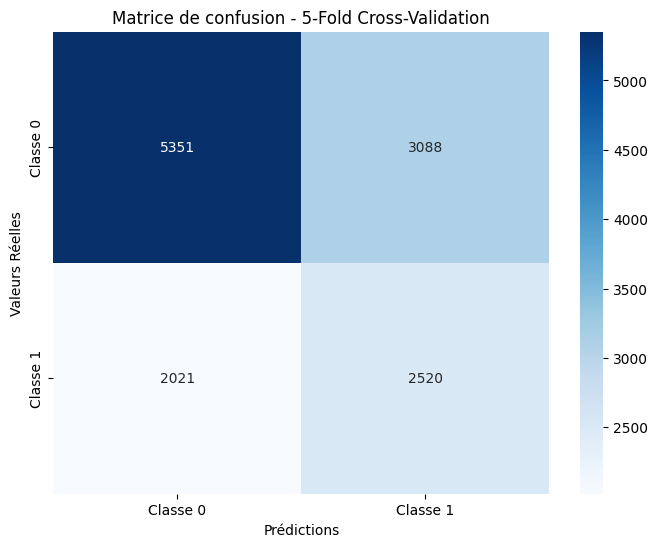

✅ Matrice de confusion sauvegardée : D:\wealth_predict_sentinel\figures_graphs\fullyConv_sans_augm_couche_gelee_batch_16_conf_matrix_sans_pca_5-fold.png


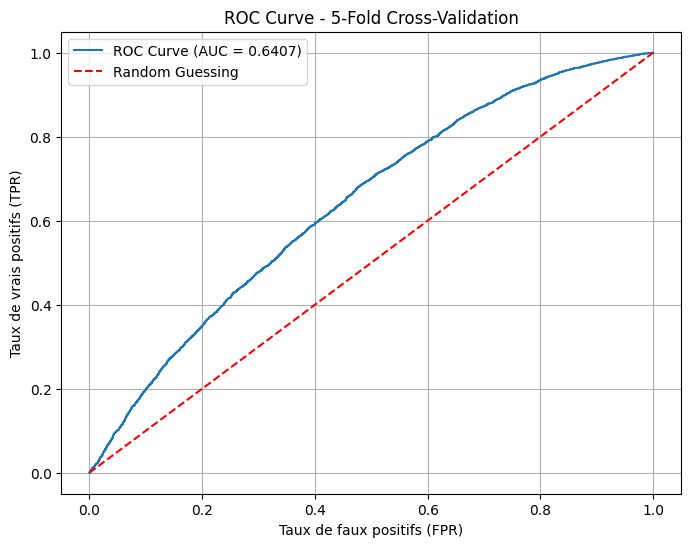

✅ Courbe ROC sauvegardée : D:\wealth_predict_sentinel\figures_graphs\fullyConv_sans_augm_couche_gelee_batch_16_roc_curve_sans_pca_5-fold.png

✅ Taux de pauvreté réel : 39.4405%
✅ Taux de pauvreté prédit : 36.6682%
✅ Fichier final sauvegardé : D:\wealth_predict_sentinel\Data\processed_csv\fullyConv_sans_augm_couche_gelee_batch_16_test_with_poverty_sans_pca_5-fold.csv
✅ Processus terminé avec succès en 0h 51m 28s.


In [5]:
import time
import os
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from joblib import Parallel, delayed
from sklearn.base import clone

start_time = time.time()

# ===============================
# 1️⃣ Définition des chemins
# ===============================
data_dir = os.path.join(base_dir, "Data", "processed_csv")
models_dir = os.path.join(base_dir, "models")
figures_dir = os.path.join(base_dir, "figures_graphs")

for path in [data_dir, models_dir, figures_dir]:
   os.makedirs(path, exist_ok=True)
   print(f"✅ Accès confirmé : {path}")

# ===============================
# 2️⃣ CHARGEMENT DES DONNÉES
# ===============================
input_csv = os.path.join(data_dir, "EHCVM_2018_images_with_features_extracted_4096_fullyConv_sans_augm_couche_gelee_batch_16_version_2.csv")
df = pd.read_csv(input_csv)

if 'pcexp_binaire' not in df.columns and 'pcexp' in df.columns and 'zref' in df.columns:
   df['pcexp_binaire'] = (df['pcexp'] <= df['zref']).astype(int)
   print("✅ La colonne 'pcexp_binaire' a été ajoutée avec succès.")

df.to_csv(input_csv, index=False)
print(f"✅ Fichier mis à jour et sauvegardé : {input_csv}")

# ===============================
# 3️⃣ PRÉTRAITEMENT DES DONNÉES
# ===============================
features = [f'feature_{i}' for i in range(4096)]
target_binary = 'pcexp_binaire'

X = df[features]
y = df[target_binary]

k = 5

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===============================
# 4️⃣ ENTRAÎNEMENT DU MODÈLE AVEC VALIDATION CROISÉE PARALLÈLE
# ===============================
def train_and_predict_fold(train_idx, test_idx, X, y, base_model):
   model = clone(base_model)
   X_train, X_test = X[train_idx], X[test_idx]
   y_train, y_test = y[train_idx], y[test_idx]

   model.fit(X_train, y_train)

   pred = model.predict(X_test)
   proba = model.predict_proba(X_test)[:, 1]

   return test_idx, pred, proba

base_model = LogisticRegression(
   class_weight='balanced',
   max_iter=10000,
   solver='saga',
   random_state=42,
   n_jobs=15
)

kf = KFold(n_splits=k, shuffle=True, random_state=42)

results = Parallel(n_jobs=-1)(
   delayed(train_and_predict_fold)(
       train_idx, test_idx, X_scaled, y, base_model
   )
   for train_idx, test_idx in kf.split(X_scaled)
)

y_pred = np.zeros_like(y, dtype=float)
y_proba = np.zeros_like(y, dtype=float)

for test_idx, pred, proba in results:
   y_pred[test_idx] = pred
   y_proba[test_idx] = proba

logistic_model = LogisticRegression(
   class_weight='balanced',
   max_iter=10000,
   solver='saga',
   random_state=42,
   n_jobs=15
)
logistic_model.fit(X_scaled, y)

# ===============================
# 5️⃣ SAUVEGARDE DU MODÈLE
# ===============================
logistic_model_path = os.path.join(models_dir, f"fullyConv_sans_augm_couche_gelee_batch_16_logistic_sans_pca_{k}-fold.pkl")
with open(logistic_model_path, 'wb') as file:
   pickle.dump((logistic_model, scaler), file)
print(f"✅ Modèle sauvegardé : {logistic_model_path}")

# ===============================
# 6️⃣ ÉVALUATION DU MODÈLE
# ===============================
print("\n✅ Rapport de classification (Test Set) :\n", classification_report(y, y_pred))

# ===============================
# 7️⃣ MATRICE DE CONFUSION
# ===============================
conf_matrix = confusion_matrix(y, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Classe 0', 'Classe 1'], yticklabels=['Classe 0', 'Classe 1'])
plt.title(f"Matrice de confusion - {k}-Fold Cross-Validation")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs Réelles")
conf_matrix_path = os.path.join(figures_dir, f"fullyConv_sans_augm_couche_gelee_batch_16_conf_matrix_sans_pca_{k}-fold.png")
plt.savefig(conf_matrix_path)
plt.show()
print(f"✅ Matrice de confusion sauvegardée : {conf_matrix_path}")

# ===============================
# 8️⃣ COURBE ROC ET AUC
# ===============================
fpr, tpr, _ = roc_curve(y, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', label="Random Guessing")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title(f"ROC Curve - {k}-Fold Cross-Validation")
plt.legend()
plt.grid(True)
roc_curve_path = os.path.join(figures_dir, f"fullyConv_sans_augm_couche_gelee_batch_16_roc_curve_sans_pca_{k}-fold.png")
plt.savefig(roc_curve_path)
plt.show()
print(f"✅ Courbe ROC sauvegardée : {roc_curve_path}")

# ===============================
# 9️⃣ CALCUL DU TAUX DE PAUVRETÉ
# ===============================
df['pcexp_binaire_pred'] = y_pred

weighted_real_poverty = (
   (df['hhweight'] * df['hhsize'] * df[target_binary]).sum() /
   (df['hhweight'] * df['hhsize']).sum()
)

weighted_predicted_poverty = (
   (df['hhweight'] * df['hhsize'] * df['pcexp_binaire_pred']).sum() /
   (df['hhweight'] * df['hhsize']).sum()
)

print(f"\n✅ Taux de pauvreté réel : {weighted_real_poverty:.4%}")
print(f"✅ Taux de pauvreté prédit : {weighted_predicted_poverty:.4%}")

# ===============================
# 🔟 SAUVEGARDE DES RÉSULTATS FINAUX
# ===============================
final_csv_path = os.path.join(data_dir, f"fullyConv_sans_augm_couche_gelee_batch_16_test_with_poverty_sans_pca_{k}-fold.csv")
df.to_csv(final_csv_path, index=False)
print(f"✅ Fichier final sauvegardé : {final_csv_path}")

end_time = time.time()
execution_time = end_time - start_time
hours = int(execution_time // 3600)
minutes = int((execution_time % 3600) // 60)
seconds = int(execution_time % 60)

print(f"✅ Processus terminé avec succès en {hours}h {minutes}m {seconds}s.")


In [6]:
import time
import pandas as pd
import numpy as np
import os

start_time = time.time()

# Chargement des données
data_dir = os.path.join(base_dir, "Data", "processed_csv")
input_file = os.path.join(data_dir, "fullyConv_sans_augm_couche_gelee_batch_16_test_with_poverty_sans_pca_5-fold.csv")

df = pd.read_csv(input_file)

def calculate_poverty_ci(df, y_proba, n_bootstrap=1000, confidence=0.95):
    np.random.seed(42)
    bootstrap_rates = []

    for _ in range(n_bootstrap):
        indices = np.random.randint(0, len(df), size=len(df))
        sample_df = df.iloc[indices]
        sample_proba = y_proba[indices]

        sample_pred = (sample_proba >= 0.5).astype(int)

        weighted_poverty = (
            (sample_df['hhweight'] * sample_df['hhsize'] * sample_pred).sum() /
            (sample_df['hhweight'] * sample_df['hhsize']).sum()
        )
        bootstrap_rates.append(weighted_poverty)

    alpha = 1 - confidence
    lower = np.percentile(bootstrap_rates, alpha/2 * 100)
    upper = np.percentile(bootstrap_rates, (1 - alpha/2) * 100)

    return lower, upper

# Calcul de l'intervalle de confiance
y_proba = df['pcexp_binaire_pred']  # Utilise les prédictions sauvegardées
lower_ci, upper_ci = calculate_poverty_ci(df, y_proba)
print(f"\n✅ Intervalle de confiance à 95% du taux de pauvreté prédit : [{lower_ci:.4%}, {upper_ci:.4%}]")

# Calcul et affichage du temps d'exécution
end_time = time.time()
execution_time = end_time - start_time
# Convertir le temps en heures, minutes et secondes
hours = int(execution_time // 3600)
minutes = int((execution_time % 3600) // 60)
seconds = int(execution_time % 60)

# Afficher le temps d'exécution avec formatage
print(f"✅ Processus terminé avec succès en {hours}h {minutes}m {seconds}s.")



✅ Intervalle de confiance à 95% du taux de pauvreté prédit : [35.5475%, 37.8222%]
✅ Processus terminé avec succès en 0h 3m 13s.


### Modèle 3:Couche Initiale nongelée - Fully Connected



✅ Accès confirmé : D:\wealth_predict_sentinel\Data\processed_csv
✅ Accès confirmé : D:\wealth_predict_sentinel\models
✅ Accès confirmé : D:\wealth_predict_sentinel\figures_graphs
✅ Fichier mis à jour et sauvegardé : D:\wealth_predict_sentinel\Data\processed_csv\EHCVM_2018_images_with_features_extracted_4096_fullyConnected_sans_augm_couche_nongelee_batch_16.csv
✅ Modèle sauvegardé : D:\wealth_predict_sentinel\models\fullyConnected_sans_augm_couche_nongelee_batch_16_logistic_sans_pca_5-fold.pkl

✅ Rapport de classification (Test Set) :
               precision    recall  f1-score   support

           0       0.72      0.63      0.67      8439
           1       0.44      0.55      0.49      4541

    accuracy                           0.60     12980
   macro avg       0.58      0.59      0.58     12980
weighted avg       0.62      0.60      0.61     12980



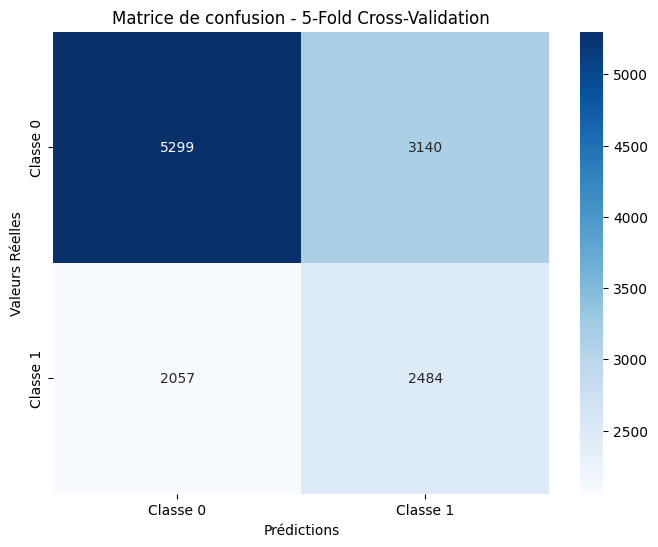

✅ Matrice de confusion sauvegardée : D:\wealth_predict_sentinel\figures_graphs\fullyConnected_sans_augm_couche_nongelee_batch_16_conf_matrix_sans_pca_5-fold.png


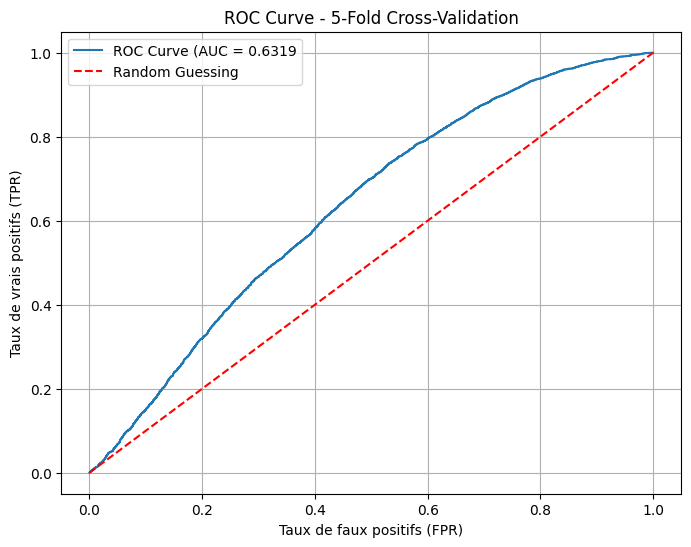

✅ Courbe ROC sauvegardée : D:\wealth_predict_sentinel\figures_graphs\fullyConnected_sans_augm_couche_nongelee_batch_16_roc_curve_sans_pca_5-fold.png

✅ Taux de pauvreté réel : 39.4405%
✅ Taux de pauvreté prédit : 37.0158%
✅ Fichier final sauvegardé : D:\wealth_predict_sentinel\Data\processed_csv\fullyConnected_sans_augm_couche_nongelee_batch_16_test_with_poverty_sans_pca_5-fold.csv
✅ Processus terminé en 3697.80 secondes.


In [7]:
import time
import os
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from joblib import Parallel, delayed
from sklearn.base import clone

start_time = time.time()

# ===============================
# 1️⃣ Définition des chemins
# ===============================
data_dir = os.path.join(base_dir, "Data", "processed_csv")
models_dir = os.path.join(base_dir, "models")
figures_dir = os.path.join(base_dir, "figures_graphs")

for path in [data_dir, models_dir, figures_dir]:
   os.makedirs(path, exist_ok=True)
   print(f"✅ Accès confirmé : {path}")

# ===============================
# 2️⃣ CHARGEMENT DES DONNÉES
# ===============================
input_csv = os.path.join(data_dir, "EHCVM_2018_images_with_features_extracted_4096_fullyConnected_sans_augm_couche_nongelee_batch_16.csv")
df = pd.read_csv(input_csv)

if 'pcexp_binaire' not in df.columns and 'pcexp' in df.columns and 'zref' in df.columns:
   df['pcexp_binaire'] = (df['pcexp'] <= df['zref']).astype(int)
   print("✅ La colonne 'pcexp_binaire' a été ajoutée avec succès.")

df.to_csv(input_csv, index=False)
print(f"✅ Fichier mis à jour et sauvegardé : {input_csv}")

# ===============================
# 3️⃣ PRÉTRAITEMENT DES DONNÉES
# ===============================
features = [f'feature_{i}' for i in range(4096)]
target_binary = 'pcexp_binaire'

X = df[features]
y = df[target_binary]

k = 5

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===============================
# 4️⃣ ENTRAÎNEMENT DU MODÈLE AVEC VALIDATION CROISÉE PARALLÈLE
# ===============================
def train_and_predict_fold(train_idx, test_idx, X, y, base_model):
   model = clone(base_model)
   X_train, X_test = X[train_idx], X[test_idx]
   y_train, y_test = y[train_idx], y[test_idx]

   model.fit(X_train, y_train)

   pred = model.predict(X_test)
   proba = model.predict_proba(X_test)[:, 1]

   return test_idx, pred, proba

base_model = LogisticRegression(
   class_weight='balanced',
   max_iter=10000,
   solver='saga',
   random_state=42,
   n_jobs=15
)

kf = KFold(n_splits=k, shuffle=True, random_state=42)

results = Parallel(n_jobs=-1)(
   delayed(train_and_predict_fold)(
       train_idx, test_idx, X_scaled, y, base_model
   )
   for train_idx, test_idx in kf.split(X_scaled)
)

y_pred = np.zeros_like(y, dtype=float)
y_proba = np.zeros_like(y, dtype=float)

for test_idx, pred, proba in results:
   y_pred[test_idx] = pred
   y_proba[test_idx] = proba

logistic_model = LogisticRegression(
   class_weight='balanced',
   max_iter=10000,
   solver='saga',
   random_state=42,
   n_jobs=15
)
logistic_model.fit(X_scaled, y)

# ===============================
# 5️⃣ SAUVEGARDE DU MODÈLE
# ===============================
logistic_model_path = os.path.join(models_dir, f"fullyConnected_sans_augm_couche_nongelee_batch_16_logistic_sans_pca_{k}-fold.pkl")
with open(logistic_model_path, 'wb') as file:
   pickle.dump((logistic_model, scaler), file)
print(f"✅ Modèle sauvegardé : {logistic_model_path}")

# ===============================
# 6️⃣ ÉVALUATION DU MODÈLE
# ===============================
print("\n✅ Rapport de classification (Test Set) :\n", classification_report(y, y_pred))

# ===============================
# 7️⃣ MATRICE DE CONFUSION
# ===============================
conf_matrix = confusion_matrix(y, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Classe 0', 'Classe 1'], yticklabels=['Classe 0', 'Classe 1'])
plt.title(f"Matrice de confusion - {k}-Fold Cross-Validation")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs Réelles")
conf_matrix_path = os.path.join(figures_dir, f"fullyConnected_sans_augm_couche_nongelee_batch_16_conf_matrix_sans_pca_{k}-fold.png")
plt.savefig(conf_matrix_path)
plt.show()
print(f"✅ Matrice de confusion sauvegardée : {conf_matrix_path}")

# ===============================
# 8️⃣ COURBE ROC ET AUC
# ===============================
fpr, tpr, _ = roc_curve(y, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'r--', label="Random Guessing")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title(f"ROC Curve - {k}-Fold Cross-Validation")
plt.legend()
plt.grid(True)
roc_curve_path = os.path.join(figures_dir, f"fullyConnected_sans_augm_couche_nongelee_batch_16_roc_curve_sans_pca_{k}-fold.png")
plt.savefig(roc_curve_path)
plt.show()
print(f"✅ Courbe ROC sauvegardée : {roc_curve_path}")

# ===============================
# 9️⃣ CALCUL DU TAUX DE PAUVRETÉ
# ===============================
df['pcexp_binaire_pred'] = y_pred

weighted_real_poverty = (
   (df['hhweight'] * df['hhsize'] * df[target_binary]).sum() /
   (df['hhweight'] * df['hhsize']).sum()
)

weighted_predicted_poverty = (
   (df['hhweight'] * df['hhsize'] * df['pcexp_binaire_pred']).sum() /
   (df['hhweight'] * df['hhsize']).sum()
)

print(f"\n✅ Taux de pauvreté réel : {weighted_real_poverty:.4%}")
print(f"✅ Taux de pauvreté prédit : {weighted_predicted_poverty:.4%}")

# ===============================
# 🔟 SAUVEGARDE DES RÉSULTATS FINAUX
# ===============================
final_csv_path = os.path.join(data_dir, f"fullyConnected_sans_augm_couche_nongelee_batch_16_test_with_poverty_sans_pca_{k}-fold.csv")
df.to_csv(final_csv_path, index=False)
print(f"✅ Fichier final sauvegardé : {final_csv_path}")

end_time = time.time()
execution_time = end_time - start_time
print(f"✅ Processus terminé en {execution_time:.2f} secondes.")


In [8]:
import time
import pandas as pd
import numpy as np
import os

start_time = time.time()

# Chargement des données
data_dir = os.path.join(base_dir, "Data", "processed_csv")
input_file = os.path.join(data_dir, "fullyConnected_sans_augm_couche_nongelee_batch_16_test_with_poverty_sans_pca_5-fold.csv")

df = pd.read_csv(input_file)

def calculate_poverty_ci(df, y_proba, n_bootstrap=1000, confidence=0.95):
    np.random.seed(42)
    bootstrap_rates = []

    for _ in range(n_bootstrap):
        indices = np.random.randint(0, len(df), size=len(df))
        sample_df = df.iloc[indices]
        sample_proba = y_proba[indices]

        sample_pred = (sample_proba >= 0.5).astype(int)

        weighted_poverty = (
            (sample_df['hhweight'] * sample_df['hhsize'] * sample_pred).sum() /
            (sample_df['hhweight'] * sample_df['hhsize']).sum()
        )
        bootstrap_rates.append(weighted_poverty)

    alpha = 1 - confidence
    lower = np.percentile(bootstrap_rates, alpha/2 * 100)
    upper = np.percentile(bootstrap_rates, (1 - alpha/2) * 100)

    return lower, upper

# Calcul de l'intervalle de confiance
y_proba = df['pcexp_binaire_pred']  # Utilise les prédictions sauvegardées
lower_ci, upper_ci = calculate_poverty_ci(df, y_proba)
print(f"\n✅ Intervalle de confiance à 95% du taux de pauvreté prédit : [{lower_ci:.4%}, {upper_ci:.4%}]")

# Calcul et affichage du temps d'exécution
end_time = time.time()
execution_time = end_time - start_time
# Convertir le temps en heures, minutes et secondes
hours = int(execution_time // 3600)
minutes = int((execution_time % 3600) // 60)
seconds = int(execution_time % 60)

# Afficher le temps d'exécution avec formatage
print(f"✅ Processus terminé avec succès en {hours}h {minutes}m {seconds}s.")



✅ Intervalle de confiance à 95% du taux de pauvreté prédit : [35.8499%, 38.1590%]
✅ Processus terminé avec succès en 0h 3m 12s.


### Modèle 4:Couche Initiale gelée - Fully Connected

✅ Accès confirmé : D:\wealth_predict_sentinel\Data\processed_csv
✅ Accès confirmé : D:\wealth_predict_sentinel\models
✅ Accès confirmé : D:\wealth_predict_sentinel\figures_graphs
✅ La colonne 'pcexp_binaire' a été ajoutée avec succès.
✅ Fichier mis à jour et sauvegardé : D:\wealth_predict_sentinel\Data\processed_csv\EHCVM_2018_images_with_features_extracted_4096_fullyConnected_sans_augm_couche_gelee_batch_16.csv
✅ Modèle sauvegardé : D:\wealth_predict_sentinel\models\fullyConnected_sans_augm_couche_gelee_batch_16_logistic_sans_pca_5-fold.pkl

✅ Rapport de classification (Test Set) :
               precision    recall  f1-score   support

           0       0.72      0.64      0.68      8439
           1       0.44      0.53      0.48      4541

    accuracy                           0.60     12980
   macro avg       0.58      0.58      0.58     12980
weighted avg       0.62      0.60      0.61     12980



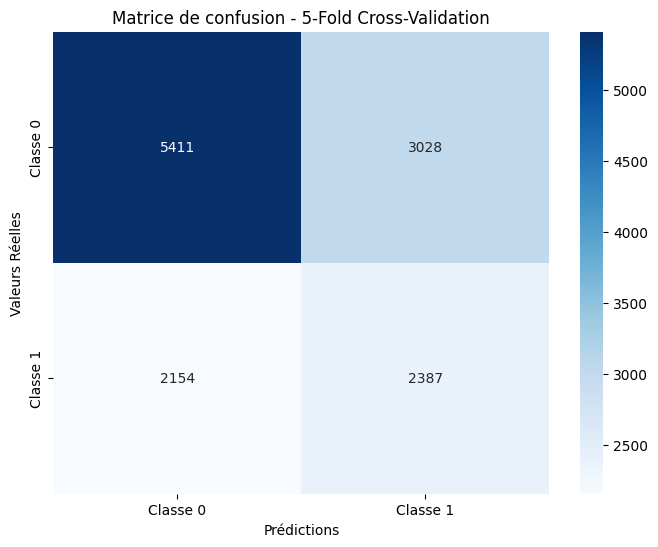

✅ Matrice de confusion sauvegardée : D:\wealth_predict_sentinel\figures_graphs\fullyConnected_sans_augm_couche_gelee_batch_16_conf_matrix_sans_pca_5-fold.png


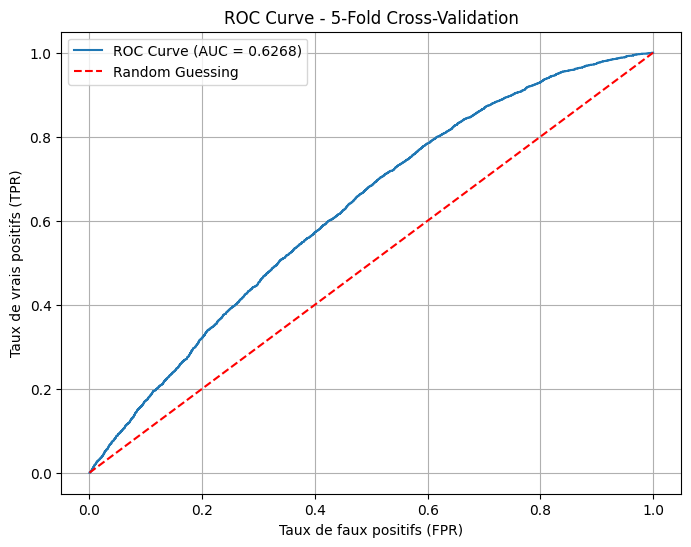

✅ Courbe ROC sauvegardée : D:\wealth_predict_sentinel\figures_graphs\fullyConnected_sans_augm_couche_gelee_batch_16_roc_curve_sans_pca_5-fold.png

✅ Taux de pauvreté réel : 39.4405%
✅ Taux de pauvreté prédit : 36.3544%
✅ Fichier final sauvegardé : D:\wealth_predict_sentinel\Data\processed_csv\fullyConnected_sans_augm_couche_gelee_batch_16_test_with_poverty_sans_pca_5-fold.csv
✅ Processus terminé avec succès en 0h 55m 49s.


In [9]:
import time
import os
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from joblib import Parallel, delayed
from sklearn.base import clone

start_time = time.time()

# ===============================
# 1️⃣ MONTAGE DE GOOGLE DRIVE
# ===============================
data_dir = os.path.join(base_dir, "Data", "processed_csv")
models_dir = os.path.join(base_dir, "models")
figures_dir = os.path.join(base_dir, "figures_graphs")

for path in [data_dir, models_dir, figures_dir]:
   os.makedirs(path, exist_ok=True)
   print(f"✅ Accès confirmé : {path}")

# ===============================
# 2️⃣ CHARGEMENT DES DONNÉES
# ===============================
input_csv = os.path.join(data_dir, "EHCVM_2018_images_with_features_extracted_4096_fullyConnected_sans_augm_couche_gelee_batch_16.csv")
df = pd.read_csv(input_csv)

if 'pcexp_binaire' not in df.columns and 'pcexp' in df.columns and 'zref' in df.columns:
   df['pcexp_binaire'] = (df['pcexp'] <= df['zref']).astype(int)
   print("✅ La colonne 'pcexp_binaire' a été ajoutée avec succès.")

df.to_csv(input_csv, index=False)
print(f"✅ Fichier mis à jour et sauvegardé : {input_csv}")

# ===============================
# 3️⃣ PRÉTRAITEMENT DES DONNÉES
# ===============================
features = [f'feature_{i}' for i in range(4096)]
target_binary = 'pcexp_binaire'

X = df[features]
y = df[target_binary]

k = 5

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===============================
# 4️⃣ ENTRAÎNEMENT DU MODÈLE AVEC VALIDATION CROISÉE PARALLÈLE
# ===============================
def train_and_predict_fold(train_idx, test_idx, X, y, base_model):
   model = clone(base_model)
   X_train, X_test = X[train_idx], X[test_idx]
   y_train, y_test = y[train_idx], y[test_idx]

   model.fit(X_train, y_train)

   pred = model.predict(X_test)
   proba = model.predict_proba(X_test)[:, 1]

   return test_idx, pred, proba

base_model = LogisticRegression(
   class_weight='balanced',
   max_iter=10000,
   solver='saga',
   random_state=42,
   n_jobs=15
)

kf = KFold(n_splits=k, shuffle=True, random_state=42)

results = Parallel(n_jobs=-1)(
   delayed(train_and_predict_fold)(
       train_idx, test_idx, X_scaled, y, base_model
   )
   for train_idx, test_idx in kf.split(X_scaled)
)

y_pred = np.zeros_like(y, dtype=float)
y_proba = np.zeros_like(y, dtype=float)

for test_idx, pred, proba in results:
   y_pred[test_idx] = pred
   y_proba[test_idx] = proba

logistic_model = LogisticRegression(
   class_weight='balanced',
   max_iter=10000,
   solver='saga',
   random_state=42,
   n_jobs=15
)
logistic_model.fit(X_scaled, y)

# ===============================
# 5️⃣ SAUVEGARDE DU MODÈLE
# ===============================
logistic_model_path = os.path.join(models_dir, f"fullyConnected_sans_augm_couche_gelee_batch_16_logistic_sans_pca_{k}-fold.pkl")
with open(logistic_model_path, 'wb') as file:
   pickle.dump((logistic_model, scaler), file)
print(f"✅ Modèle sauvegardé : {logistic_model_path}")

# ===============================
# 6️⃣ ÉVALUATION DU MODÈLE
# ===============================
print("\n✅ Rapport de classification (Test Set) :\n", classification_report(y, y_pred))

# ===============================
# 7️⃣ MATRICE DE CONFUSION
# ===============================
conf_matrix = confusion_matrix(y, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Classe 0', 'Classe 1'], yticklabels=['Classe 0', 'Classe 1'])
plt.title(f"Matrice de confusion - {k}-Fold Cross-Validation")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs Réelles")
conf_matrix_path = os.path.join(figures_dir, f"fullyConnected_sans_augm_couche_gelee_batch_16_conf_matrix_sans_pca_{k}-fold.png")
plt.savefig(conf_matrix_path)
plt.show()
print(f"✅ Matrice de confusion sauvegardée : {conf_matrix_path}")

# ===============================
# 8️⃣ COURBE ROC ET AUC
# ===============================
fpr, tpr, _ = roc_curve(y, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', label="Random Guessing")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title(f"ROC Curve - {k}-Fold Cross-Validation")
plt.legend()
plt.grid(True)
roc_curve_path = os.path.join(figures_dir, f"fullyConnected_sans_augm_couche_gelee_batch_16_roc_curve_sans_pca_{k}-fold.png")
plt.savefig(roc_curve_path)
plt.show()
print(f"✅ Courbe ROC sauvegardée : {roc_curve_path}")

# ===============================
# 9️⃣ CALCUL DU TAUX DE PAUVRETÉ
# ===============================
df['pcexp_binaire_pred'] = y_pred

weighted_real_poverty = (
   (df['hhweight'] * df['hhsize'] * df[target_binary]).sum() /
   (df['hhweight'] * df['hhsize']).sum()
)

weighted_predicted_poverty = (
   (df['hhweight'] * df['hhsize'] * df['pcexp_binaire_pred']).sum() /
   (df['hhweight'] * df['hhsize']).sum()
)

print(f"\n✅ Taux de pauvreté réel : {weighted_real_poverty:.4%}")
print(f"✅ Taux de pauvreté prédit : {weighted_predicted_poverty:.4%}")

# ===============================
# 🔟 SAUVEGARDE DES RÉSULTATS FINAUX
# ===============================
final_csv_path = os.path.join(data_dir, f"fullyConnected_sans_augm_couche_gelee_batch_16_test_with_poverty_sans_pca_{k}-fold.csv")
df.to_csv(final_csv_path, index=False)
print(f"✅ Fichier final sauvegardé : {final_csv_path}")

end_time = time.time()
execution_time = end_time - start_time
hours = int(execution_time // 3600)
minutes = int((execution_time % 3600) // 60)
seconds = int(execution_time % 60)

print(f"✅ Processus terminé avec succès en {hours}h {minutes}m {seconds}s.")


In [14]:
import os
import pickle
import pandas as pd
from sklearn.preprocessing import StandardScaler


base_dir = r"D:\wealth_predict_sentinel"
#data_dir = os.path.join(base_dir, "Data", "processed_csv")
# Définition des chemins 
input_csv_2023 = os.path.join(base_dir, "Data/processed_csv/images_with_features_extracted_4096_fullyConnected_sans_augm_couche_gelee_batch_16_base_EHCVM_2018_pour_an_2023.csv")
model_path = os.path.join(base_dir, "models/fullyConnected_sans_augm_couche_gelee_batch_16_logistic_sans_pca_5-fold.pkl")
output_dir_csv = os.path.join(base_dir, "Data/processed_csv")

# Chargement des données de 2023
df_2023 = pd.read_csv(input_csv_2023)

# Vérification des colonnes nécessaires
features = [f'feature_{i}' for i in range(4096)]
required_columns = features + ['hhweight', 'hhsize']

missing_columns = [col for col in required_columns if col not in df_2023.columns]
if missing_columns:
    raise ValueError(f"Les colonnes suivantes sont manquantes dans les données de 2023 : {missing_columns}")

X_2023 = df_2023[features]

# Normalisation des données avec un scaler basé sur 2023
scaler = StandardScaler()
X_2023_scaled = scaler.fit_transform(X_2023)
X_2023_sans_pca = X_2023_scaled

# Chargement du modèle
with open(model_path, 'rb') as file:
    logistic_model, _ = pickle.load(file)

print(type(logistic_model))

# Prédictions
y_pred_2023 = logistic_model.predict(X_2023_sans_pca)
df_2023['pcexp_binaire_pred'] = y_pred_2023

# Calcul du taux de pauvreté prévisionnel
weighted_predicted_poverty_2023 = (
    (df_2023['hhweight'] * df_2023['hhsize'] * df_2023['pcexp_binaire_pred']).sum() /
    (df_2023['hhweight'] * df_2023['hhsize']).sum()
)

print(f"Taux de pauvreté prévisionnel en 2023 : {weighted_predicted_poverty_2023:.4%}")

# Sauvegarde des résultats
final_csv_path = os.path.join(output_dir_csv, "fullyConnected_sans_augm_couche_gelee_batch_16_test_with_poverty_2023_logistic_reg.csv")
df_2023.to_csv(final_csv_path, index=False)

print(f"Les prédictions ont été sauvegardées dans : {final_csv_path}")

# Définition des chemins sur Google Drive pour 2021
input_csv_2021 = os.path.join(base_dir, "Data/processed_csv/images_with_features_extracted_4096_fullyConnected_sans_augm_couche_gelee_batch_16_base_EHCVM_2018_pour_an_2021.csv")
model_path = os.path.join(base_dir, "models/fullyConnected_sans_augm_couche_gelee_batch_16_logistic_sans_pca_5-fold.pkl")

# Chargement des données de 2021
df_2021 = pd.read_csv(input_csv_2021)

# Vérification des colonnes nécessaires
missing_columns = [col for col in required_columns if col not in df_2021.columns]
if missing_columns:
    raise ValueError(f"Les colonnes suivantes sont manquantes dans les données de 2021 : {missing_columns}")

X_2021 = df_2021[features]

# Normalisation des données avec un scaler basé sur 2021
scaler = StandardScaler()
X_2021_scaled = scaler.fit_transform(X_2021)
X_2021_sans_pca = X_2021_scaled

# Chargement du modèle
with open(model_path, 'rb') as file:
    logistic_model, _ = pickle.load(file)

print(type(logistic_model))

# Prédictions
y_pred_2021 = logistic_model.predict(X_2021_sans_pca)
df_2021['pcexp_binaire_pred'] = y_pred_2021

# Calcul du taux de pauvreté prévisionnel
weighted_predicted_poverty_2021 = (
    (df_2021['hhweight'] * df_2021['hhsize'] * df_2021['pcexp_binaire_pred']).sum() /
    (df_2021['hhweight'] * df_2021['hhsize']).sum()
)

print(f"Taux de pauvreté prévisionnel en 2021 : {weighted_predicted_poverty_2021:.4%}")

# Sauvegarde des résultats
final_csv_path = os.path.join(output_dir_csv, "fullyConnected_sans_augm_couche_gelee_batch_16_test_with_poverty_2021_logistic_reg.csv")
df_2021.to_csv(final_csv_path, index=False)

print(f"Les prédictions ont été sauvegardées dans : {final_csv_path}")


<class 'sklearn.linear_model._logistic.LogisticRegression'>
Taux de pauvreté prévisionnel en 2023 : 40.5476%
Les prédictions ont été sauvegardées dans : D:\wealth_predict_sentinel\Data/processed_csv\fullyConnected_sans_augm_couche_gelee_batch_16_test_with_poverty_2023_logistic_reg.csv
<class 'sklearn.linear_model._logistic.LogisticRegression'>
Taux de pauvreté prévisionnel en 2021 : 42.7575%
Les prédictions ont été sauvegardées dans : D:\wealth_predict_sentinel\Data/processed_csv\fullyConnected_sans_augm_couche_gelee_batch_16_test_with_poverty_2021_logistic_reg.csv
